<a href="https://colab.research.google.com/github/mrnobody075/Helmet-and-Head-Detection-Using-YOLO-for-Safety-Monitoring/blob/main/helmet_detection_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 55.8 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()  # choose helmet_dataset.zip


In [ ]:
!unzip helmet-dataset.zip -d /content/helmet-dataset




In [18]:
!yolo detect train \
  model=yolov10m.pt \
  data=/content/helmet-dataset/data.yaml \
  epochs=100 \
  imgsz=764 \
  batch=16 \
  patience=20


Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet-dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=764, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=True,

In [8]:
from ultralytics import YOLO

# 1) Load your trained model
model = YOLO("/content/train3/weights/best.pt")

# 2) Run detection on one image
results = model("/content/person-with-helmet.jpg", conf=0.25, save=True)

# 3) Show basic info
print(results)



image 1/1 /content/person-with-helmet.jpg: 448x640 1 helmet, 965.8ms
Speed: 5.3ms preprocess, 965.8ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'head', 1: 'helmet', 2: 'person'}
obb: None
orig_img: array([[[ 43,  80, 130],
        [ 61,  98, 156],
        [ 54,  88, 164],
        ...,
        [ 13,  20,  29],
        [ 13,  20,  29],
        [ 13,  20,  29]],

       [[ 24,  59, 109],
        [ 39,  73, 132],
        [ 45,  77, 152],
        ...,
        [ 12,  19,  28],
        [ 12,  19,  28],
        [ 12,  19,  28]],

       [[  8,  41,  90],
        [ 12,  46, 100],
        [ 30,  60, 131],
        ...,
        [ 12,  19,  28],
        [ 12,  19,  28],
        [ 12,  19,  28]],

       ...,

       [[ 61,  78,  91],
        [ 66,  83,  96],
        [ 66,  83,  96],
  

In [9]:
from ultralytics.utils.plotting import Annotator
import cv2

# get first (and only) result
r = results[0]

# class names (should be ['head', 'helmet', 'person'])
names = model.names
print("Class names:", names)

# boxes, confidences, class ids
boxes = r.boxes

for box in boxes:
    cls_id = int(box.cls[0].item())       # class index
    cls_name = names[cls_id]              # class name string
    conf = float(box.conf[0].item())      # confidence
    xyxy = box.xyxy[0].tolist()           # [x1, y1, x2, y2]

    print(f"Detected {cls_name} with conf {conf:.2f} at {xyxy}")


Class names: {0: 'head', 1: 'helmet', 2: 'person'}
Detected helmet with conf 0.93 at [309.0805969238281, 29.6352481842041, 453.36700439453125, 195.37850952148438]


In [10]:
has_helmet = False
has_head_without_helmet = False

for box in boxes:
    cls_id = int(box.cls[0].item())
    cls_name = names[cls_id]

    if cls_name == "helmet":
        has_helmet = True
    if cls_name == "head":
        has_head_without_helmet = True

print("Has helmet in image:", has_helmet)
print("Has head without helmet in image:", has_head_without_helmet)


Has helmet in image: True
Has head without helmet in image: False


Saving pexels-olly-926390.jpg to pexels-olly-926390 (1).jpg

image 1/1 /content/pexels-olly-926390 (1).jpg: 448x640 1 head, 24.5ms
Speed: 3.5ms preprocess, 24.5ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict3

DETECTIONS:
   head | conf=0.93 | box=(2859, 847, 4416, 2598)


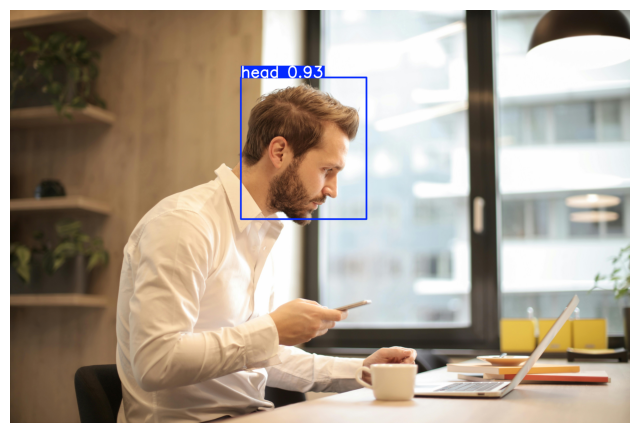

In [19]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from google.colab import files

# === Upload image ===
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]

# === Load trained model (EDIT THIS PATH IF NEEDED) ===
MODEL_PATH = "/content/runs/detect/train3/weights/best.pt"
model = YOLO(MODEL_PATH)

# === Run detection ===
results = model(IMAGE_PATH, conf=0.25, save=True)
r = results[0]
names = model.names
boxes = r.boxes

# === Print bounding boxes ===
print("\nDETECTIONS:")
for b in boxes:
    cls = int(b.cls[0].item())
    cls_name = names[cls]
    conf = float(b.conf[0].item())
    x1, y1, x2, y2 = b.xyxy[0].tolist()
    print(f"{cls_name:>7} | conf={conf:.2f} | box=({round(x1)}, {round(y1)}, {round(x2)}, {round(y2)})")

# === Show image with bounding boxes ===
annotated = r.plot()
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(annotated_rgb)
plt.axis('off')
plt.show()


In [5]:
!yolo detect val \
  model=/content//train3/weights/best.pt \
  data=/content/helmet-dataset/data.yaml \
  conf=0.25 \
  iou=0.5 \
  plots=True


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv10m summary (fused): 136 layers, 15,314,905 parameters, 0 gradients, 58.9 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 184.5±88.5 MB/s, size: 38.9 KB)
val: Scanning /content/helmet-dataset/valid/labels... 160 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 160/160 710.3it/s 0.2s
val: New cache created: /content/helmet-dataset/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 30.7s/it 5:07
                   all        160        824      0.941       0.54      0.597      0.391
                  